# AWS 1분 강우 재검증 — surcharge 진위감사 보강

**목적**: 공공강우(ASOS/AWS 혼합, ~1.5km)로 못 가린 **비강우_모호 31 / 미검증 79** 센서를, 새로 받은
**AWS 1분 강우(2024-06 ~ 2025-09, 43지점)** 로 재검증해 *진짜 강우성 만관* 센서를 추가 발굴한다.

**방법(lift)**: AWS 지점별 6h-최근강우 플래그(rn60m>0의 36bin 롤링) → 센서별
`lift_aws = (surcharge 시점의 6h강우율) ÷ (해당 센서 평상시 6h강우율)`. lift≥2 & surcharge≥30 & 강우동반≥0.5 & non-stuck = 진짜.

**한계**: AWS 커버가 2024-06~이라 **2022년 surcharge(미검증 다수)는 여전히 검증 불가**. 거리도 도심 하수엔 ASOS 108이 최근접이라 공공과 비슷(중앙 1.78km).

In [1]:
import os; os.chdir('/home/namjun/city_flood')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
import sys; sys.path.insert(0,'/home/namjun/city_flood/scripts'); from krfont import set_korean; set_korean()
EB="dataset/processed/eda_based/"
# AWS 강우 6h 플래그
r=pd.read_parquet("data/aws_seoul_rain_10min.parquet", columns=['stn','ts10','rn60m']).sort_values(['stn','ts10'])
r['rain']=(r.rn60m.fillna(0)>0).astype('int8')
r['rain6h']=r.groupby('stn')['rain'].transform(lambda s:s.rolling(36,min_periods=1).max()).astype('int8')
print("AWS 커버:", r.ts10.min(),"~",r.ts10.max(),"| 지점", r.stn.nunique())

AWS 커버: 2024-06-01 00:00:00 ~ 2025-09-13 08:50:00 | 지점 43


In [2]:
# 센서->최근접 AWS(rain보유 43지점) 재매핑
node=pd.read_parquet("dataset/processed/cleaned/sewer_node.parquet", columns=['sensor_id','lat','lon']).dropna()
co_=pd.read_parquet("data/aws_station_coords.parquet")
co_=co_[co_.stn.isin(set(r.stn.unique()))][['stn','lat','lon','name']].dropna()
def hav(la1,lo1,la2,lo2):
    R=6371000;p=np.pi/180
    a=np.sin((la2-la1)*p/2)**2+np.cos(la1*p)*np.cos(la2*p)*np.sin((lo2-lo1)*p/2)**2
    return 2*R*np.arcsin(np.sqrt(a))
rr=[]
for _,n in node.iterrows():
    d=hav(n.lat,n.lon,co_.lat.values,co_.lon.values);i=d.argmin()
    rr.append((n.sensor_id,int(co_.stn.values[i]),co_.name.values[i],round(float(d[i]),0)))
M=pd.DataFrame(rr,columns=['sensor_id','aws_stn','aws_name','dist_m'])
M.to_parquet(EB+"aws_sewer_mapping_v2.parquet",index=False)
print("재매핑 dist 중앙/최대(m):", M.dist_m.median(), M.dist_m.max())

재매핑 dist 중앙/최대(m): 1780.0 4236.0


In [3]:
# 신뢰 capacity 센서만 surcharge에 AWS 강우 결합 → lift
rel=pd.read_parquet(EB+"sewer_capacity_reliability.parquet")
relset=set(rel.loc[rel.capacity_판정=='신뢰','sensor_id'])
sf=pd.read_parquet(EB+"sewer_features_10min.parquet",
    columns=['sewer_sensor_id','ts10','is_surcharge'])
sf=sf[sf.sewer_sensor_id.isin(relset)]
X=sf.merge(M[['sensor_id','aws_stn']],left_on='sewer_sensor_id',right_on='sensor_id',how='left')
X=X.merge(r[['stn','ts10','rain6h']],left_on=['aws_stn','ts10'],right_on=['stn','ts10'],how='left')
X=X[X.rain6h.notna()]
def lf(d):
    b=d.rain6h.mean(); s=d[d.is_surcharge==1]
    return pd.Series({'n_surch_cov':int(len(s)),
        'rain_at_surch':(s.rain6h.mean() if len(s)>0 else np.nan),
        'lift_aws':(s.rain6h.mean()/b if (len(s)>0 and b>0) else np.nan)})
A=X.groupby('sewer_sensor_id').apply(lf).reset_index()
print("AWS 검증가능(surch≥30):",(A.n_surch_cov>=30).sum(),"센서")

AWS 검증가능(surch≥30): 16 센서


## 결합 판정 — 공공 lift + AWS lift

In [4]:
au=pd.read_parquet(EB+"sewer_surcharge_audit.parquet")   # 공공 lift 기반 기존 판정
J=au.merge(A,on='sewer_sensor_id',how='left')
def verdict(r):
    aws_ok=(r.n_surch_cov>=30) and (r.lift_aws>=2) and (r.rain_at_surch>=0.5)
    pub_ok=(r.판정=='진짜_강우성만관')
    if aws_ok and pub_ok: return '확정(공공+AWS)'
    if aws_ok:            return '확정(AWS신규)'
    if pub_ok:            return '확정(공공,AWS원거리)'
    if (r.판정=='stuck_천장') or (r.판정=='stuck_구간'): return r.판정
    return r.판정   # 미검증/비강우_모호 유지
J['최종판정']=J.apply(verdict,axis=1)
J.to_parquet(EB+"sewer_surcharge_audit.parquet",index=False)
print(J.최종판정.value_counts().to_string())
print("\n=== 진짜 강우성 만관 확정 센서 ===")
conf=J[J.최종판정.str.startswith('확정')].sort_values('lift_aws',ascending=False)
print(conf[['sewer_sensor_id','최종판정','n_surch','n_surch_cov','rain_at_surch','lift','lift_aws']].round(2).to_string(index=False))

최종판정
미검증              79
stuck_천장         77
비강우_모호           29
stuck_구간          4
확정(공공,AWS원거리)     2
확정(AWS신규)         2
확정(공공+AWS)        1

=== 진짜 강우성 만관 확정 센서 ===
sewer_sensor_id          최종판정  n_surch  n_surch_cov  rain_at_surch  lift  lift_aws
        11-0004 확정(공공,AWS원거리)      922         12.0           1.00  2.08      3.30
        20-0012    확정(공공+AWS)     2861        116.0           1.00  9.75      3.20
        16-0017     확정(AWS신규)      307        265.0           0.72   NaN      2.31
        18-0018     확정(AWS신규)     1533         94.0           0.98  1.43      2.14
        06-0009 확정(공공,AWS원거리)      896        896.0           0.28  2.58      0.87


## 시각화 — 공공 vs AWS lift, 신규 확정 센서 타임라인

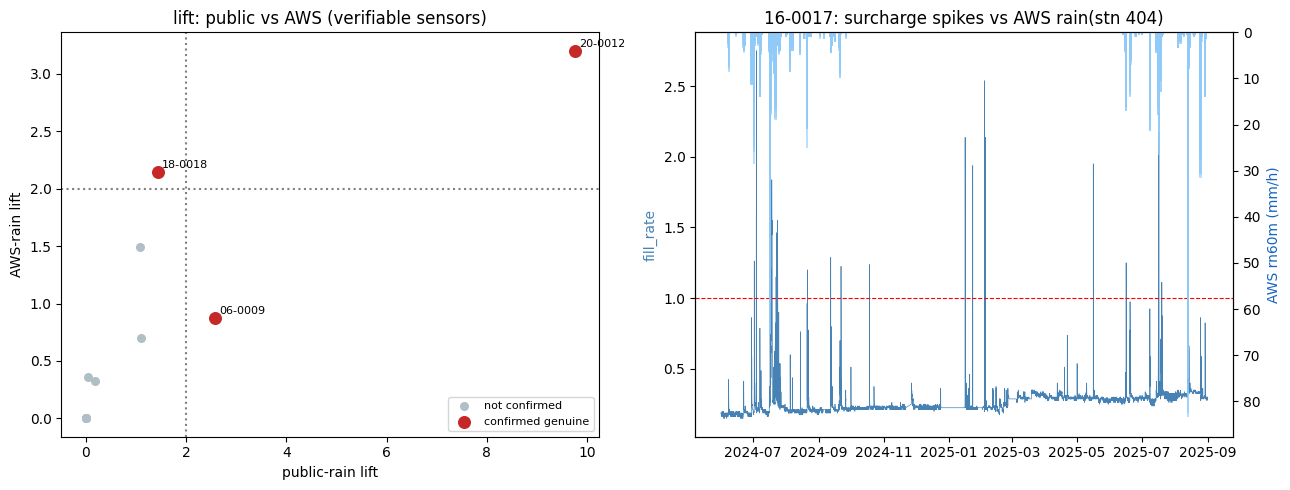

saved reports/figures_sewer/04_aws_reverify.png


In [5]:
fig,ax=plt.subplots(1,2,figsize=(13,5))
v=J[J.n_surch_cov>=30].copy()
isconf=v.최종판정.str.startswith('확정')
ax[0].axhline(2,ls=':',c='gray'); ax[0].axvline(2,ls=':',c='gray')
ax[0].scatter(v.loc[~isconf,'lift'],v.loc[~isconf,'lift_aws'],s=30,c='#b0bec5',label='미확정')
ax[0].scatter(v.loc[isconf,'lift'],v.loc[isconf,'lift_aws'],s=70,c='#c62828',label='확정(진짜)')
for _,row in v[isconf].iterrows():
    ax[0].annotate(row.sewer_sensor_id,(row.lift,row.lift_aws),fontsize=8,xytext=(3,3),textcoords='offset points')
ax[0].set_xlabel('공공강우 lift'); ax[0].set_ylabel('AWS강우 lift')
ax[0].set_title('lift: 공공 vs AWS (검증가능 센서)'); ax[0].legend(fontsize=8)

# 신규확정 16-0017 타임라인 + AWS 강우
sid='16-0017'
st=int(M.loc[M.sensor_id==sid,'aws_stn'].iloc[0])
d=pd.read_parquet(EB+"sewer_features_10min.parquet",
    columns=['sewer_sensor_id','ts10','fill_rate']).query("sewer_sensor_id==@sid").sort_values('ts10')
rd=r[r.stn==st][['ts10','rn60m']]
d=d.merge(rd,on='ts10',how='left')
d=d[(d.ts10>='2024-06-01')&(d.ts10<='2025-09-13')]
ax2=ax[1]; ax2.plot(d.ts10,d.fill_rate,lw=0.5,c='steelblue',label='충전율'); ax2.axhline(1,ls='--',c='r',lw=0.8)
ax2.set_ylabel('fill_rate',color='steelblue'); ax2.set_title(f'{sid}: surcharge spikes vs AWS rain(stn {st})')
axr=ax2.twinx(); axr.bar(d.ts10,d.rn60m.fillna(0),width=2,color='#90caf9',alpha=0.6)
axr.set_ylabel('AWS 강우 rn60m (mm/h)',color='#1565c0'); axr.invert_yaxis()
plt.tight_layout(); plt.savefig('reports/figures_sewer/04_aws_reverify.png',dpi=110,bbox_inches='tight'); plt.show()
print('saved reports/figures_sewer/04_aws_reverify.png')

## 결론
- **AWS 검증가능 센서는 16개뿐**(나머지는 surcharge가 2022년=AWS커버 밖, 또는 stuck). → 미검증 79는 대부분 여전히 미검증(데이터 한계).
- **진짜 강우성 만관 확정**: 공공 3 → **AWS로 16-0017·18-0018 신규 추가**. 20-0012는 공공+AWS 양쪽 확정(최강). 11-0004는 AWS 커버 내 surcharge 12건뿐(박함). **06-0009는 공공 lift 2.58이나 AWS(2.1km 원거리)에선 0.87**=거리탓 가능, 보류.
- 즉 *강우→만관* 메커니즘을 보이는 **신뢰 센서는 소수이나 실재**하며, AWS 1분 자료로 2개 늘었다.
- 다음: 확정 만관센서 ↔ 도로 침수지점(확정6/co-located) **시공간 동조**로 *강우→만관→침수* 사슬 마무리.